# Exploratory Data Analysis

This notebook covers the exploration analysis of the rental listings dataset:
missing value analysis, outlier detection, inspection of the distributions, correlation analysis and exploration of the text features.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
dev_path = "data/raw/development.csv"
eval_path = "data/raw/evaluation.csv"
listings_dev = pd.read_csv(dev_path)
listings_eval = pd.read_csv(eval_path)

In [3]:
listings_dev.head(5)

,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_type,square_feet,address,cityname,state,latitude,longitude,source,time,id
0,housing/rent/apartment,"Move-in condition, Two BR One BA. $760/mo",Cobalt Springs combines the comfort of small-t...,"Clubhouse,Playground",1.0,2.0,USD,No,Yes,"Cats,Dogs",...,Monthly,930,NaN,Taylors,SC,34.9339,-82.3211,RentDigs.com,1544244125,0
1,housing/rent/apartment,This Apartment is a must see!,Awesome recently remodeled 2 beds one bathroom...,"Garbage Disposal,Parking,Storage,Washer Dryer,...",1.0,2.0,USD,No,Yes,NaN,...,Monthly,750,NaN,Los Angeles,CA,34.0809,-118.1774,RentDigs.com,1568752016,1
2,housing/rent/apartment,Euless Luxurious 1 + 1,The Arbors of Euless Apartments located in Eul...,"Clubhouse,Fireplace,Parking,Patio/Deck,Storage...",1.0,1.0,USD,No,Yes,"Cats,Dogs",...,Monthly,652,NaN,Euless,TX,32.8524,-97.0886,RentDigs.com,1568778961,2
3,housing/rent/apartment,"Move-in condition, Two BR Two BA",Secluded surroundings and the unexpected conve...,NaN,2.0,2.0,USD,No,Yes,NaN,...,Monthly,841,NaN,Elkridge,MD,39.2031,-76.7531,RentDigs.com,1568776387,3
4,housing/rent/apartment,Prominence Apartments Two BR Luxury Apartment ...,"Square footage: 900 square feet, unit number: ...",Washer Dryer,1.0,2.0,USD,No,No,Cats,...,Monthly,900,NaN,Bismarck,ND,46.8630,-100.7686,RentDigs.com,1550844561,4


We make the conversion of square feet to float64 and of the time feature to the right type.

In [4]:
listings_dev['square_feet'] = listings_dev['square_feet'].astype('float64')
listings_eval['square_feet'] = listings_eval['square_feet'].astype('float64')
listings_dev['time'] = pd.to_datetime(listings_dev['time'], origin='unix', unit='s')
listings_eval['time'] = pd.to_datetime(listings_eval['time'], origin='unix', unit='s')

## Missing values

List of attributes together with their non Nan values counts.

In [5]:
listings_dev.info()

<class 'pandas.DataFrame'>
RangeIndex: 79589 entries, 0 to 79588
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   category      79589 non-null  str          
 1   title         79589 non-null  str          
 2   body          79589 non-null  str          
 3   amenities     66785 non-null  str          
 4   bathrooms     79538 non-null  float64      
 5   bedrooms      79500 non-null  float64      
 6   currency      79589 non-null  str          
 7   fee           79589 non-null  str          
 8   has_photo     79589 non-null  str          
 9   pets_allowed  31269 non-null  str          
 10  price         79589 non-null  float64      
 11  price_type    79589 non-null  str          
 12  square_feet   79589 non-null  float64      
 13  address       6363 non-null   str          
 14  cityname      79355 non-null  str          
 15  state         79355 non-null  str          
 16  latitude      7

Compute the percentage of missing values for each attribute.

In [6]:
listings_dev.isnull().sum(axis=0) / len(listings_dev) * 100

category         0.000000
title            0.000000
body             0.000000
amenities       16.087650
bathrooms        0.064079
bedrooms         0.111824
currency         0.000000
fee              0.000000
has_photo        0.000000
pets_allowed    60.711907
price            0.000000
price_type       0.000000
square_feet      0.000000
address         92.005177
cityname         0.294010
state            0.294010
latitude         0.028898
longitude        0.028898
source           0.000000
time             0.000000
id               0.000000
dtype: float64

We can explore closer the relationship between missing values from different features. In particular, the relation bewtween missing bathrooms and bedrooms, and that of latitude/longitude and cityname/state.

In [7]:
listings_dev_explore = listings_dev.copy()

In [8]:
(listings_dev_explore['bathrooms'].isnull() & listings_dev_explore['bedrooms'].isnull()).sum() == listings_dev_explore['bathrooms'].isnull().sum()

np.False_

This implies that there could be cases where bathrooms is missings but bedrooms is present and viceversa.

In [9]:
(listings_dev_explore['state'].isnull() & listings_dev_explore['cityname'].isnull()).sum() == listings_dev_explore['state'].isnull().sum()


np.True_

This implies that every time state is missing even cityname is missing.

For the geographical informations, we see that there are 23 listings whose locations are completely unknown and 234 whose position could by infered by latitude and longitude, for example looking for the nearest neighboors.

In [10]:
print((listings_dev_explore['latitude'].isnull() & listings_dev_explore['cityname'].isnull()).sum() == listings_dev_explore['cityname'].isnull().sum())
print((listings_dev_explore['latitude'].isnull() & listings_dev_explore['cityname'].isnull()).sum())
print(listings_dev_explore['cityname'].isnull().sum())

False
23
234


In [11]:
lat_missing = listings_dev_explore['latitude'].isnull()
print(f"Listings with missing latitude/longitude: {lat_missing.sum()}")
print(f"cityname also missing: {listings_dev_explore.loc[lat_missing, 'cityname'].isnull().sum()}")
print(f"state also missing: {listings_dev_explore.loc[lat_missing, 'state'].isnull().sum()}")

Listings with missing latitude/longitude: 23
cityname also missing: 23
state also missing: 23


We can propose some methods to address the presence of missing values:

* Amenities: the presence of missing values in this field could be due to listings without amenities associated. Therefore, one strategy to address them could be to set them to "None" or "".

* Bathrooms and bedrooms: in this case, missing values could be simply non-reported values. This conclusion is encouraged by the presence of zero in the bedrooms feature. Their missing values can be infered through the square feet feature.

* Pets_allowed: missing values might correspond to cases where pets are not allowed or are simply non reported, so they could be solved simply by setting them to "Missing" or "".

* Address: this feature contains a lot of missing values, therefore it might not be informative for the task.

* Cityname/state: their missing values could be inferred, one of the possibilities is using their relation with latitude and longitude.

* Latitude / longitude: their missing values can not be inferred, since in these cases any geographical information is missing.



## Distributions of numerical attributes

We now analyze the presence and nature of noise in numerical attributes.

Let's plot the distributions of numerical attributes.

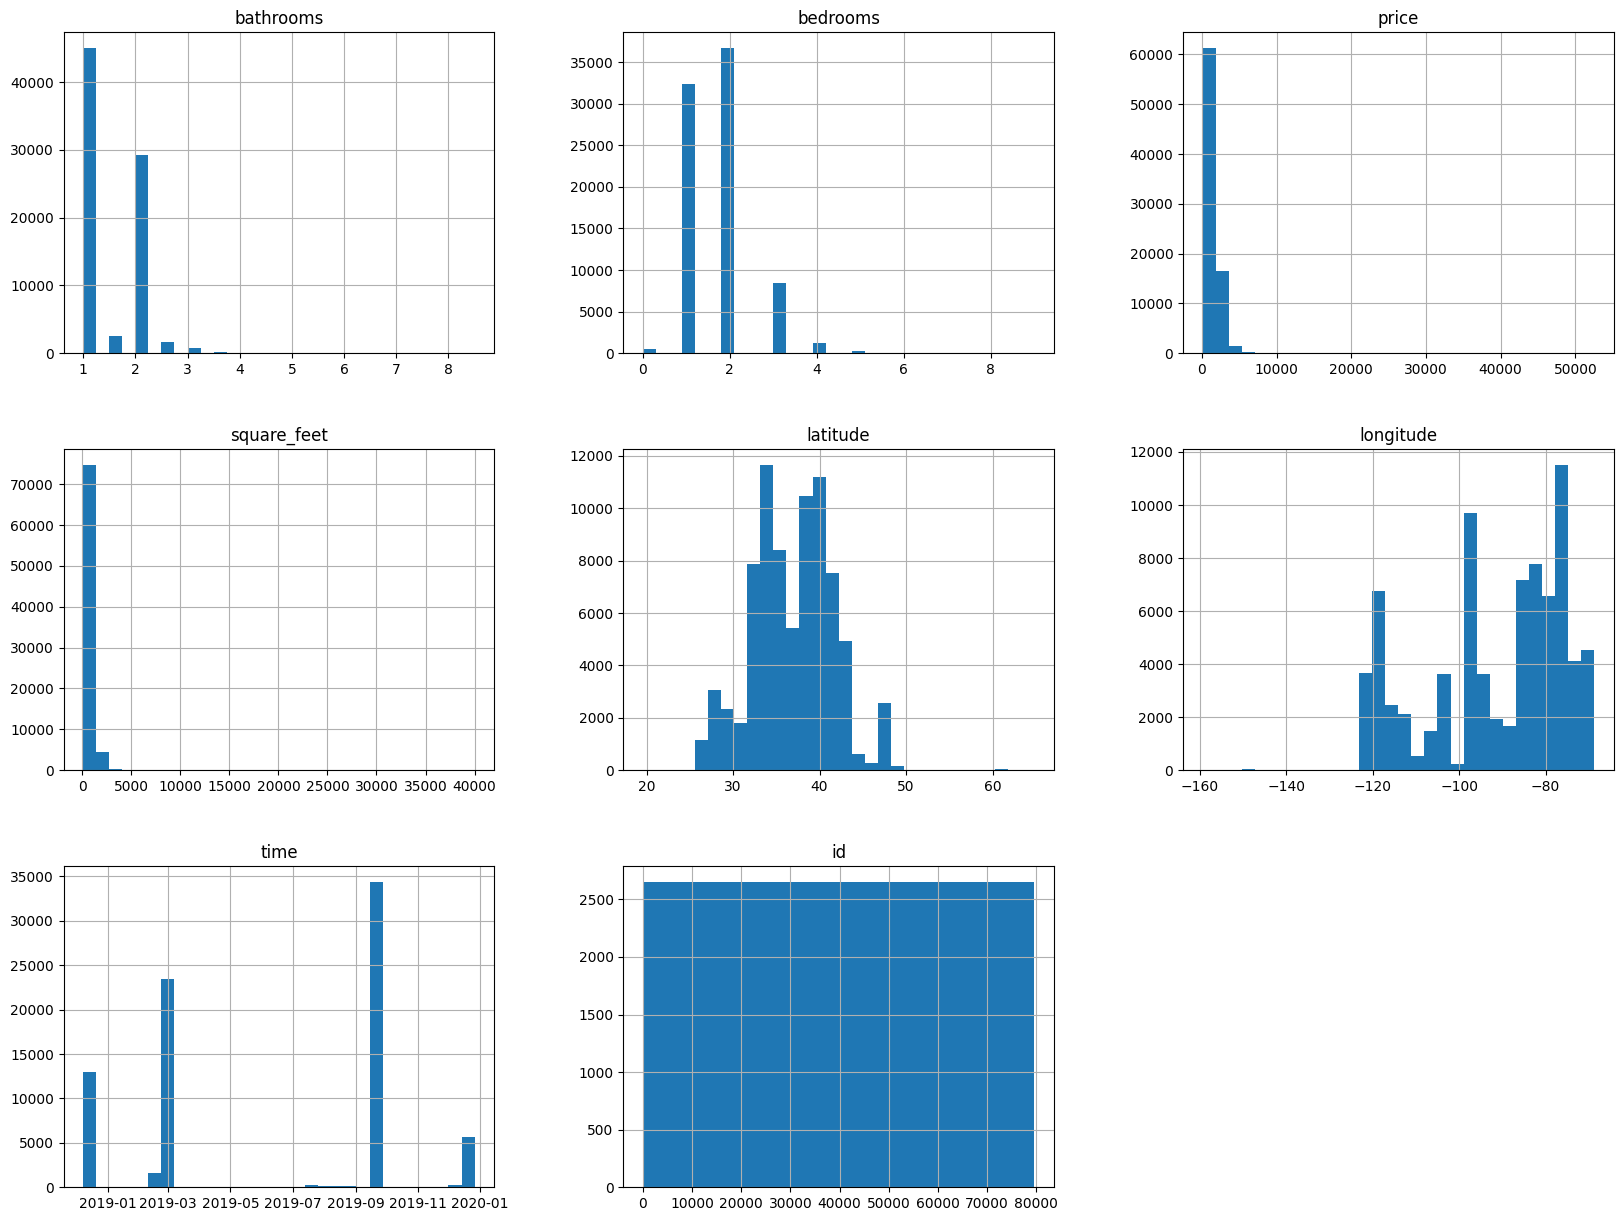

In [12]:
listings_dev_explore.hist(bins=30, figsize=(20,15))
plt.show()


In [13]:
listings_dev_explore.describe()

,bathrooms,bedrooms,price,square_feet,latitude,longitude,time,id
count,79538.000000,79500.000000,79589.000000,79589.000000,79566.000000,79566.000000,79589,79589.000000
mean,1.444152,1.726503,1525.025983,955.424493,36.954013,-91.567827,2019-06-04 08:38:06,39794.000000
min,1.000000,0.000000,100.000000,101.000000,19.573800,-159.369800,2018-12-07 09:20:18,0.000000
25%,1.000000,1.000000,1010.000000,728.000000,33.749600,-104.791900,2019-02-22 10:30:46,19897.000000
50%,1.000000,2.000000,1350.000000,900.000000,37.228200,-84.564300,2019-09-17 18:28:56,39794.000000
75%,2.000000,2.000000,1795.000000,1115.000000,39.955900,-77.612800,2019-09-18 00:36:05,59691.000000
max,8.500000,9.000000,52500.000000,40000.000000,64.833200,-68.778800,2019-12-26 20:17:05,79588.000000
std,0.546014,0.747902,892.078246,391.491641,4.599936,15.809975,NaN,22975.509624


Bedrooms and bathrooms features have some outliers. They represent rare cases not impossible cases, but they might be capped.

Price and square_feet features have very skewed distributions. One possible way to reduce the skewness is to apply a trasformation (i.e. log-trasform).
There are several points supporting the application of a log-trasformation: it reduces the variance, it reduce noise by skweezing large values, it mitigates the effects of outliers and allows to represent the widely studied log-log relation between price and square_feet in the real estate market.  
To manage far square feet outliers, we could aggregate them.

We can compare the plot of the price distribution with the log trasfromed one.

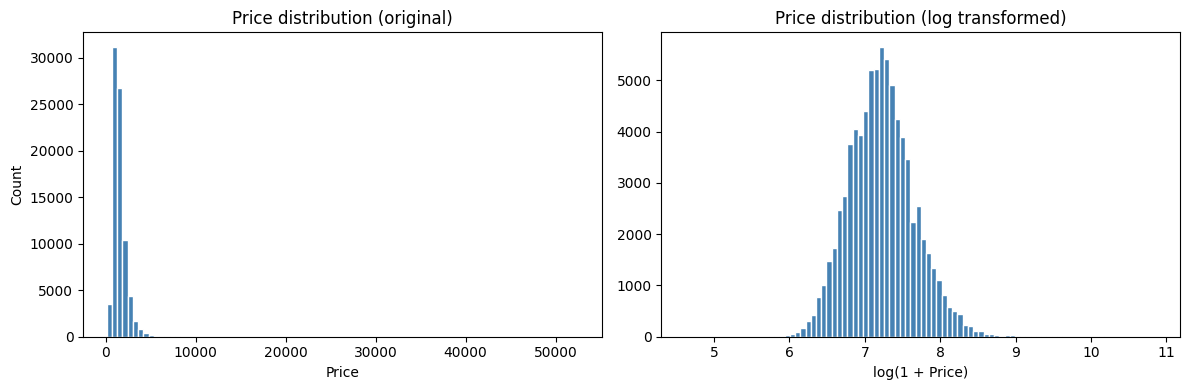

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(listings_dev_explore['price'], bins=90, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')
axes[0].set_title('Price distribution (original)')

axes[1].hist(np.log1p(listings_dev_explore['price']), bins=90, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_title('Price distribution (log transformed)')
plt.tight_layout()
plt.show()

Let's analyze the geographical coordinates.

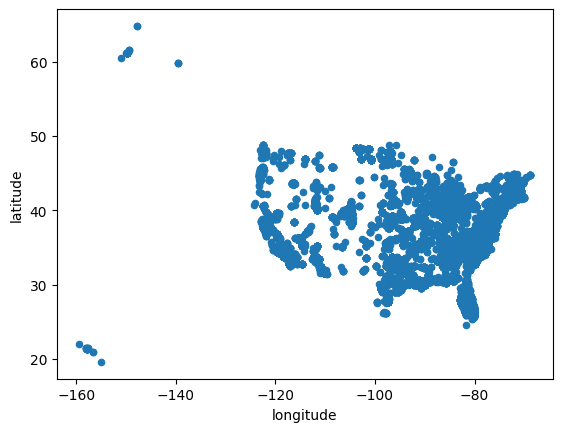

In [15]:
listings_dev_explore.plot(kind="scatter", x="longitude", y="latitude")
plt.show()

Let's visualize the listings density.

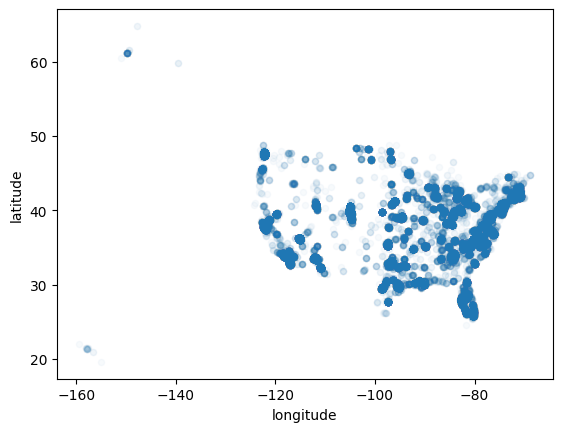

In [16]:
listings_dev_explore.plot(kind="scatter", x="longitude", y="latitude", alpha=0.03)
plt.show()

There might be some outliers. Let's investigate them more closely.

In [17]:
len(listings_dev_explore[(listings_dev_explore['longitude'] < -135)]) 

68

In [18]:
listings_dev_explore[(listings_dev_explore['longitude'] < -135)]['cityname'].value_counts()

cityname
Anchorage      37
Honolulu        8
Wasilla         3
Yakutat         3
Waipahu         2
Fairbanks       2
Lahaina         2
Kailua          2
Eagle River     2
Lihue           1
Keaau           1
Kapolei         1
Mililani        1
Kaaawa          1
Kaneohe         1
Soldotna        1
Name: count, dtype: int64

These are listings of cities in Alaska and Hawaii. They are fews to make any significant statistical conclusion.

The following scatter plot shows that high prices are more concentrated in certains states (i.e. California). It mights be a useful information.

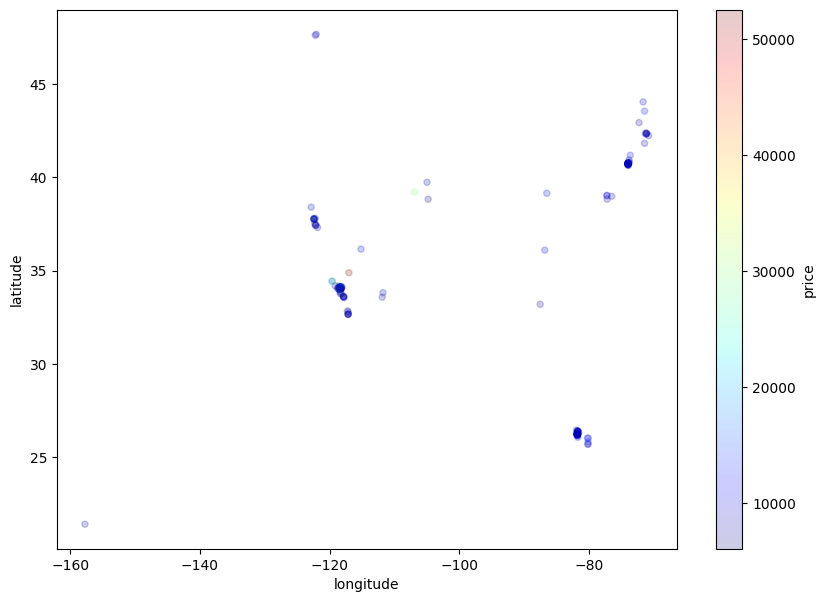

In [19]:
listings_dev_explore[listings_dev_explore['price'] > 6000].plot(kind="scatter", x="longitude", y="latitude", alpha=0.2,
            figsize=(10,7), c="price", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.show()


Let's analyze the temporal feature.

<Axes: xlabel='month', ylabel='price'>

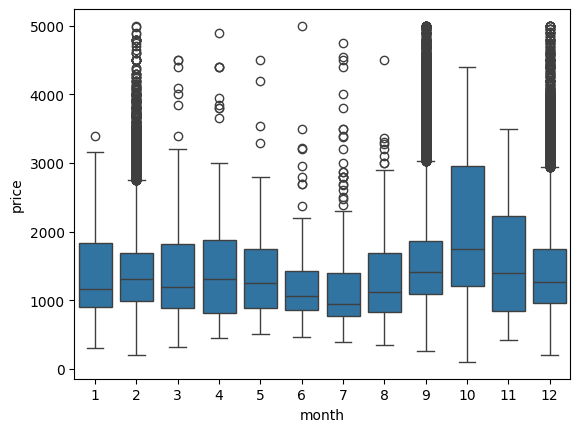

In [20]:
listings_dev_explore['month'] = listings_dev_explore['time'].dt.month
listings_dev_explore['day'] = listings_dev_explore['time'].dt.day
sns.boxplot(x='month', y='price', data=listings_dev_explore[listings_dev_explore['price'] < 5000])

There could be a seasonal trend, but it could be a spurious pattern.

In [21]:
listings_dev_explore['month'].value_counts()

month
9     34469
2     25030
12    18838
7       385
8       241
6       140
3       103
1       100
4        99
5        93
10       58
11       33
Name: count, dtype: int64

In [22]:
listings_dev_explore[listings_dev_explore['month'] == 2]['day'].value_counts()

day
22    24982
18        8
14        5
12        4
24        4
27        4
17        4
20        3
9         3
23        2
7         2
26        2
25        1
10        1
13        1
11        1
3         1
19        1
5         1
Name: count, dtype: int64

In [23]:
listings_dev_explore[(listings_dev_explore['month'] == 2) & (listings_dev_explore['day'] == 22)]['source'].value_counts()


source
RentDigs.com    24982
Name: count, dtype: int64

These are very interesting results. The temporal features do not capture meaningful seasonality or trends and may introduce spurious patterns in the model. In fact, we have seen that the listings are very concentrated on a few days in a few months, and after looking at the sources providing these listings, we have understood that this pattern suggests that the distribution of posting dates is not driven by real market dynamics, but rather by technical factors such as bulk uploads.

## Distribution of categorical attributes

In the following, we are going to study the distribution of categorical attributes.

In [24]:
listings_dev_explore = listings_dev.copy()
categorical = ['category', 'amenities', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price_type', 'cityname', 'state', 'source']
for attribute in categorical:
    print(listings_dev_explore[attribute].value_counts())
    print()

category
housing/rent/apartment            79538
housing/rent/commercial/retail       36
housing/rent                          6
housing/rent/home                     4
housing/rent/short_term               2
housing/rent/condo                    2
housing/rent/other                    1
Name: count, dtype: int64

amenities
Parking                                                                                                                                             4967
Parking,Storage                                                                                                                                     1663
Gym,Pool                                                                                                                                            1530
Pool                                                                                                                                                1194
Gym,Parking,Pool                                              

The following attributes have almost non zero variance, as a result they could be removed before training the models: category, currency, fee and price_type.  
Pets allowed has not almost non zero variance because we have to consider the remaining significant part of missing values which should be infered.

In [25]:
listings_dev_explore.groupby("source")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
Apartable,1.0,869.000000,NaN,869.0,869.00,869.0,869.00,869.0
BostonApartments,74.0,3006.513514,865.862263,1475.0,2400.00,2837.5,3500.00,5350.0
Claz,7.0,1102.285714,417.899396,695.0,839.00,900.0,1324.00,1795.0
GoSection8,350.0,1034.240000,439.910859,350.0,775.00,926.5,1187.50,3600.0
Home Rentals,6.0,994.166667,285.909368,625.0,827.50,950.0,1177.50,1400.0
HousesForRent,1.0,2500.000000,NaN,2500.0,2500.00,2500.0,2500.00,2500.0
Listanza,24.0,2226.875000,999.053696,750.0,1787.50,2125.0,2558.75,4790.0
ListedBuy,454.0,1123.548458,697.978798,350.0,770.00,957.0,1345.00,11000.0
Nest Seekers,4.0,8066.500000,4863.875924,2950.0,4799.50,7708.0,10975.00,13900.0


Although some sources present different mean prices, the intra-source variance is very high, which reduces the informative value of the source feature. Additionally, the distribution of the price feature is highly imbalanced, with over more than 90% of the listings belonging to RentDigs. Therefore, this feature is unlikely to provide meaningful predictive info and it could be removed.

In [26]:
listings_dev_explore.groupby('state')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
state,,,,,,,,
AK,48.0,1067.416667,329.032355,685.0,856.25,945.0,1266.25,2032.0
AL,282.0,948.198582,531.106771,285.0,671.25,823.0,1089.50,7000.0
AR,485.0,874.692784,279.124381,200.0,700.00,825.0,975.00,2900.0
AZ,1899.0,1119.169563,419.057096,350.0,853.50,1081.0,1334.00,8500.0
CA,8247.0,2457.643143,1630.027959,493.0,1675.00,2195.0,2810.00,52500.0
CO,4971.0,1551.174412,613.448915,313.0,1267.50,1475.0,1749.00,30000.0
CT,383.0,1273.169713,399.070819,100.0,982.00,1185.0,1480.00,3350.0
DC,79.0,2174.367089,818.778079,790.0,1633.00,1926.0,2602.50,4995.0
DE,6.0,997.500000,444.890436,755.0,800.00,812.5,885.00,1900.0


State categories have very different price means, therefore the state feature could be informative. The same happens with the cityname feature as shown, for example, by the prices of cities in CA.

In [27]:
listings_dev_explore[listings_dev_explore['state'] == 'CA' ].groupby('cityname')['price'].describe().head(30)

,count,mean,std,min,25%,50%,75%,max
cityname,,,,,,,,
Adelanto,5.0,761.000000,66.932802,675.0,725.00,775.0,775.00,855.0
Agoura Hills,6.0,2558.666667,234.275621,2361.0,2388.25,2476.5,2656.25,2963.0
Alameda,6.0,2353.166667,279.936719,2095.0,2170.75,2238.5,2508.75,2800.0
Alhambra,15.0,2322.866667,483.943749,1495.0,2147.50,2441.0,2661.50,2955.0
Aliso Viejo,8.0,2517.125000,450.852664,1899.0,2168.00,2553.0,2902.25,3095.0
Alpine,3.0,1723.333333,672.780301,1320.0,1335.00,1350.0,1925.00,2500.0
Altadena,2.0,1700.000000,565.685425,1300.0,1500.00,1700.0,1900.00,2100.0
American Canyon,5.0,2195.200000,159.317921,2009.0,2069.00,2209.0,2289.00,2400.0
Anaheim,35.0,1784.685714,446.703532,900.0,1510.00,1620.0,1886.00,2875.0


In [28]:
min_value = 100
counts = listings_dev_explore['cityname'].value_counts()
num_rare_cities = (counts < min_value).sum()
print(num_rare_cities)
print(counts)


2629
cityname
Dallas         2301
Denver         2163
Los Angeles    1915
Las Vegas      1469
Arlington      1251
               ... 
Cabin John        1
Gonzales          1
El Macero         1
Sebastian         1
Saint Johns       1
Name: count, Length: 2806, dtype: int64


Cityname has a lot of rare categories. They could create a lot of noise for the models, in particular if we will preprocess cityname with one-hot encoding. It will be better to aggregate rare categories.  
A similar reasoning can be applied to the state feature.

## Correlation

In the following we are going to study the correlation and MI coefficient between numerical attributes and the price target. We will log-trasform price and square_feet and will look at their new distributions. Log trasform is a common trasformation applied to the price and square_feet features, to fit better their well studied relation in the real estate market: log(price) = b*log(square_feet) + ....

In [29]:
from sklearn.feature_selection import mutual_info_regression


listings_dev_explore['log_price'] = np.log1p(listings_dev_explore['price'])
listings_dev_explore['log_square_feet'] = np.log1p(listings_dev_explore['square_feet'])

X = listings_dev_explore.select_dtypes(include=['number']).dropna()
y = X['price']
X = X.drop(columns=['price', 'log_price', 'log_square_feet'])

mi = mutual_info_regression(X, y)

mi_df = pd.DataFrame({'Feature': X.columns, 'MI': mi})

mi_df = mi_df.sort_values(by='MI', ascending=False)

print(mi_df)


       Feature        MI
4    longitude  0.762834
3     latitude  0.667112
2  square_feet  0.432568
0    bathrooms  0.099121
1     bedrooms  0.073648
5           id  0.003384


In [30]:
corr_matrix = listings_dev_explore.select_dtypes(include=['number']).corr()

In [31]:
corr_matrix["price"].sort_values(ascending=False)

price              1.000000
log_price          0.865626
square_feet        0.386062
log_square_feet    0.351943
bathrooms          0.321340
bedrooms           0.230669
latitude           0.057627
id                 0.003155
longitude         -0.106444
Name: price, dtype: float64

We can see that the log trasforms, applied to square feet and price, increases their correlation coefficient.

In [32]:
corr_matrix["log_price"].sort_values(ascending=False)

log_price          1.000000
price              0.865626
log_square_feet    0.395443
square_feet        0.371729
bathrooms          0.338555
bedrooms           0.248066
latitude           0.090969
id                 0.000203
longitude         -0.092262
Name: log_price, dtype: float64

This is the correlations heatmap associated to the original numerical attributes.

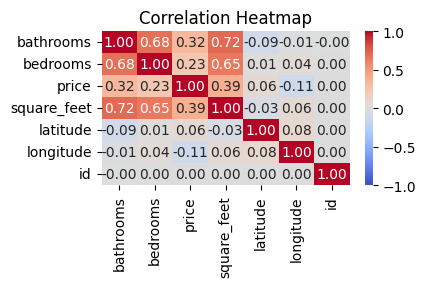

In [33]:
plt.figure(figsize=(4, 2))
sns.heatmap(
    listings_dev_explore.drop(columns=['log_price', 'log_square_feet'])
        .select_dtypes(include=['number'])
        .corr(),
    annot=True,
    fmt=".2f", 
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('Correlation Heatmap')
plt.show()

As expected, id shows very little correlation with the price. In addition, any time-related information in the dataset is spurious, and therefore id does not contain any meaningful temporal information. So it can be removed.

## Categorical variables vs Price

We study how categorical features relate to the listing price.

We check whether the presence of a photo is associated with higher prices.

In [34]:
print(listings_dev_explore['has_photo'].value_counts())
print()
stats = listings_dev_explore.groupby('has_photo')['price'].agg(['mean', 'median', 'count']).round(1)
print(stats)

has_photo
Yes          44909
Thumbnail    27404
No            7276
Name: count, dtype: int64

             mean  median  count
has_photo                       
No         1606.1  1428.0   7276
Thumbnail  1463.6  1299.0  27404
Yes        1549.4  1370.0  44909


The output shows that the precence of a photo does not imply higher prices. Anyway, the feature is informative because there is difference between categories.

We check if the amenities feature is important for predicting the price.

In [35]:
from sklearn.preprocessing import MultiLabelBinarizer

amenities_lists = (listings_dev_explore['amenities']
    .fillna('').str.split(',')
    .apply(lambda x: [a.strip() for a in x if a.strip()]))

mlb_eda = MultiLabelBinarizer()
amenities_encoded = pd.DataFrame(
    mlb_eda.fit_transform(amenities_lists),
    columns=mlb_eda.classes_,
    index=listings_dev_explore.index
)

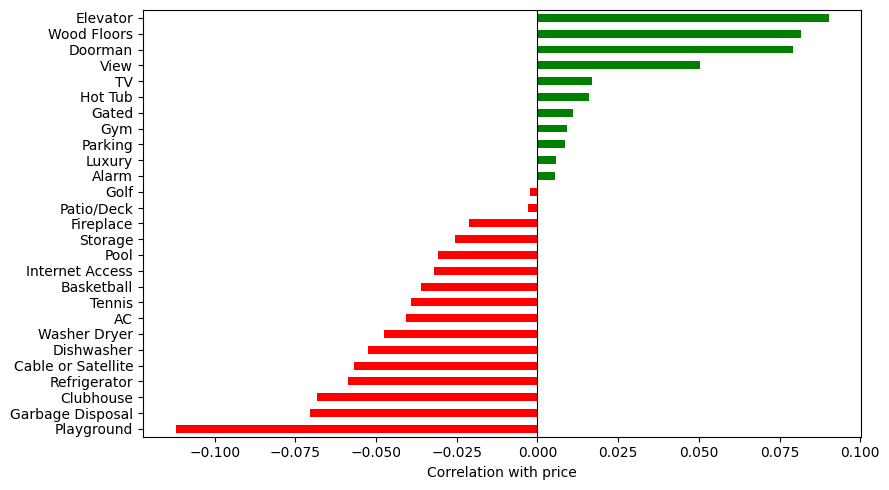

In [36]:
amenity_corr = amenities_encoded.corrwith(listings_dev_explore['price']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['green' if c > 0 else 'red' for c in amenity_corr.values[::-1]]
amenity_corr[::-1].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with price')
plt.tight_layout()
plt.show()

From the plot we can see that the amenities feature is informative.

Let's analyze the title feature.

In [37]:
listings_dev_explore['title_length'] = listings_dev_explore['title'].apply(lambda x: len(x))
print(listings_dev_explore['title_length'].value_counts())
print(listings_dev_explore[listings_dev_explore['title_length'] == 27]['title'].value_counts())
print(listings_dev_explore[listings_dev_explore['title_length'] == 27]['source'].value_counts())

title_length
27    2642
31    2636
50    2586
42    2488
32    2448
      ... 
5        5
7        3
8        3
4        2
3        2
Name: count, Length: 78, dtype: int64
title
Apartment in great location    811
Apartment in prime location    807
Attractive Three BR, Two BA     49
We're Cat and Dog Friendly!     15
Attractive Three BR, One BA     10
                              ... 
Three BR 645 E. Central Ave      1
Two BR 6229 E. Seaside Walk      1
One BR 200-206 W. Maple St.      1
Two BR Apartment in Bothell      1
One BR 235 Ironworks Avenue      1
Name: count, Length: 828, dtype: int64
source
RentDigs.com        2233
RentLingo            372
ListedBuy             18
RealRentals           10
Listanza               4
tenantcloud            2
GoSection8             1
RENTCafé               1
BostonApartments       1
Name: count, dtype: int64


A lot of titles are made by templates and are posted by the same sources.

This suggests that full titles are not informative, but extracting only some keywords that are a significant correlation with price can still be useful.

We vectorize the full title and then compute the correlation between the one-hot encoded words represntations of words with the price. We highlight that we decided to remove geographical keywords since are already present in the geographical features. This is necessary since without this step many of them appear among the keywords.

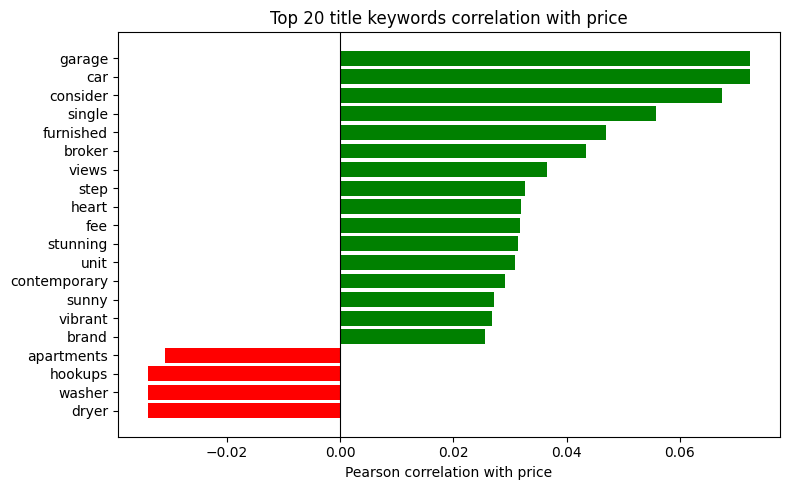

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

geo_words = set()
for city in listings_dev_explore['cityname'].dropna().unique():
    geo_words.update(city.lower().split())
for state in listings_dev_explore['state'].dropna().unique():
    geo_words.add(state.lower())
custom_stop_words = list(ENGLISH_STOP_WORDS | geo_words)

def get_keyword_correlations(texts, prices, max_features=1000, min_df=50):
    vec = CountVectorizer(max_features=max_features, min_df=min_df, stop_words=custom_stop_words)
    X = vec.fit_transform(texts.fillna(''))
    words = vec.get_feature_names_out()
    corrs = [(word, np.corrcoef(X[:, i].toarray().flatten(), prices)[0, 1])
             for i, word in enumerate(words)]
    return pd.DataFrame(corrs, columns=['word', 'corr']).sort_values('corr', key=abs, ascending=False)

corrs_title_df = get_keyword_correlations(
    listings_dev_explore['title'], listings_dev_explore['price']
)
title_keywords = corrs_title_df.head(25)['word'].tolist()

top20 = corrs_title_df.head(20).sort_values('corr')
colors = ['red' if c < 0 else 'green' for c in top20['corr']]
plt.figure(figsize=(8, 5))
plt.barh(top20['word'], top20['corr'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Top 20 title keywords correlation with price")
plt.xlabel('correlation with price')
plt.tight_layout()
plt.show()


Let's analyze the body feature.

In [39]:
listings_dev_explore['body_length'] = listings_dev_explore['body'].apply(lambda x: len(x))
print(listings_dev_explore['body_length'].value_counts())

body_length
1023     767
1021     747
1022     711
1019     674
1020     666
        ... 
29400      1
85440      1
91         1
60         1
11714      1
Name: count, Length: 977, dtype: int64


From the distribution of bodies it seems that the body feature suffers of the same problem of title. In fact, a lot of bodies have similar or equal patterns and lot of them are made by the same few sources. We can focus only on keywords as we did with title.


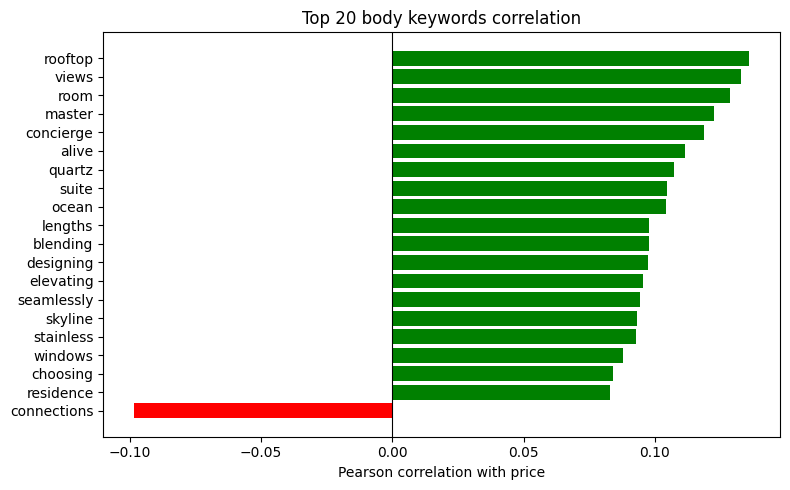

In [ ]:
corrs_body_df = get_keyword_correlations(
    listings_dev_explore['body'], listings_dev_explore['price']
)
body_keywords = corrs_body_df.head(25)['word'].tolist()

top20_body = corrs_body_df.head(20).sort_values('corr')
colors = ['red' if c < 0 else 'green' for c in top20_body['corr']]
plt.figure(figsize=(8, 5))
plt.barh(top20_body['word'], top20_body['corr'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('correlation with price')
plt.title('Top 20 body keywords correlation with price')
plt.tight_layout()
plt.show()
